<a href="https://colab.research.google.com/github/Pmskabir1234/Torch/blob/main/TinyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import torch
import matplotlib.pyplot as plt

In [58]:
x = torch.tensor(6.45)   #suppose CGPA
y = torch.tensor(0.0)   #a binary class instance: 1 -> Placed, 0 -> Not Placed

w = torch.tensor(1., requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [59]:
def bce_loss(y_pred, y):
  epsilon = 1e-8
  y = torch.clamp(y, epsilon, 1-epsilon)
  return -(y_pred*torch.log(y) + (1-y)*torch.log(1-y_pred))

In [60]:
lr = 0.05
loss_plot = []

for i in range(5):
  z = w*x + b
  y_pred = torch.sigmoid(z)

  l = bce_loss(y_pred, y)
  loss_plot.append(l.detach())
  print(f"Epoch {i+1} :")
  print(f"Loss: {l.item():.4f} W: {w.item():.4f} B: {b.item():.4f}")

  l.backward()
  with torch.no_grad():
    w.data -= lr*w.grad
    b.data -= lr*b.grad

  w.grad.zero_()
  b.grad.zero_()



Epoch 1 :
Loss: 24.8432 W: 1.0000 B: 0.0000
Epoch 2 :
Loss: 22.4399 W: 0.6686 B: -0.0514
Epoch 3 :
Loss: 17.1877 W: 0.2692 B: -0.1133
Epoch 4 :
Loss: 0.0747 W: -0.8179 B: -0.2818
Epoch 5 :
Loss: 0.0638 W: -0.8419 B: -0.2856


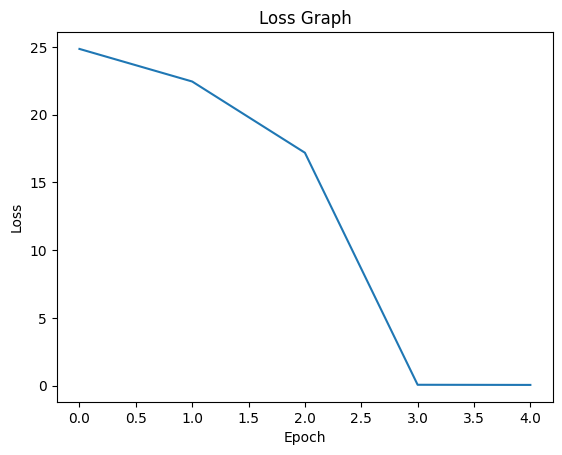

In [61]:
plt.plot(loss_plot)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.show()

##Key Points:

1. Used ***required_grad = True*** for weight and bias since the loss function is differentiated wrt w & b to compute grdient and update parameters.

2. Experiment with ***lr*** to notice changes in convergence, high lr gives faster convergence while low lr gives slower convergene. Experiment and determine the optimized value.

3. Both l and l.detach() are tensor but we use l.detach() to store loss values to plot. Since l is part of computational graph so pytorch tracks all operations performed on l to perform *automatic differentiation*.
As we don't want the graph plotting to be part of computational graph we use l.detch() which gives:
    i. better memomry usage
    ii. no interfrence with computational graph

4. w.data is used make changes in the raw data saved in tensor. Since w,b are part of computational graph and tracked for a automatic differentiation, we use ***torch.no_grad()*** and ***.data*** to keep things working and optimized.

5. w.data -= lr*w.grad is the same as w.add_(-lr*w.grad)